In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import joblib

In [2]:
data = pd.read_csv('../rolled_data_24_25.csv', index_col=0)


## GK


In [3]:
gk_feats = joblib.load('./hist/feats_gk')
gk_models_by_round = joblib.load('./models_by_round_gk')

gk_data = data[data['position'] == 'Goalkeeper']

cached_model = None
mae_by_round = {}
r2_by_round = {}

gk_preds = pd.DataFrame()

for ro in range(6, 39):

    preds = {}
    tar_feats = gk_feats[ro].copy()
    tar_feats.remove('xP')

    X_train = gk_data[gk_data['round'] < ro][tar_feats]
    y_train = gk_data[gk_data['round'] < ro]['xP']
    c = abs(y_train.min()) + 1.0
    y_train_shifted = y_train + c

    X_test = gk_data[gk_data['round'] == ro][tar_feats]
    X_test_index = gk_data[gk_data['round'] == ro]['element']
    X_test_names = gk_data[gk_data['round'] == ro]['name']
    y_test = gk_data[gk_data['round'] == ro]['xP']


    if ro in [22, 32, 34]:
        model = cached_model
        tar_feats = gk_feats[ro-1].copy()
        tar_feats.remove('xP')

        # X_train = gk_data[gk_data['round'] < ro][tar_feats]
        # y_train = gk_data[gk_data['round'] < ro]['xP']
        # c = abs(y_train.min()) + 1.0
        # y_train_shifted = y_train + c

        X_test = gk_data[gk_data['round'] == ro][tar_feats]
        X_test_index = gk_data[gk_data['round'] == ro]['element']
        X_test_names = gk_data[gk_data['round'] == ro]['name']
        y_test = gk_data[gk_data['round'] == ro]['xP']

    else:
        model = gk_models_by_round[ro]

        best_model = model['best_model']

        if 'best_estimator' in gk_models_by_round[ro]:
            model = gk_models_by_round[ro]['best_estimator'].regressor # not fitted yet
        else:
            model = RandomForestRegressor()


        model.fit(X_train, y_train_shifted)

    xP_preds = model.predict(X_test) - c

    # print(f"Best Estimator for Round {ro}: {best_estimator}")

    xP_preds = model.predict(X_test) - c

    preds['element'] = X_test_index.values
    preds['name'] = X_test_names.values

    preds['xP_pred'] = xP_preds
    preds['xP_actual'] = y_test.values
    preds['round'] = ro

    mae = mean_absolute_error(y_test, xP_preds)
    rmse = np.sqrt(mean_squared_error(y_test, xP_preds))
    r2 = r2_score(y_test, xP_preds)

    mae_by_round[ro] = mae
    r2_by_round[ro] = r2

    print(f"Round {ro} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    gk_preds = pd.concat([gk_preds, pd.DataFrame(preds)], ignore_index=True)

    cached_model = model

gk_preds



Round 6 - MAE: 0.5343, RMSE: 0.8545, R2: 0.7518
Round 7 - MAE: 0.5681, RMSE: 0.9814, R2: 0.7309
Round 8 - MAE: 0.6811, RMSE: 1.0320, R2: 0.6581
Round 9 - MAE: 0.5374, RMSE: 0.8132, R2: 0.7748
Round 10 - MAE: 0.5133, RMSE: 0.7744, R2: 0.7658
Round 11 - MAE: 0.4808, RMSE: 0.7075, R2: 0.8182
Round 12 - MAE: 0.4654, RMSE: 0.7320, R2: 0.8290
Round 13 - MAE: 0.4756, RMSE: 0.7464, R2: 0.7593
Round 14 - MAE: 0.5797, RMSE: 0.7831, R2: 0.7757
Round 15 - MAE: 0.3900, RMSE: 0.5664, R2: 0.8039
Round 16 - MAE: 0.4128, RMSE: 0.6784, R2: 0.7616
Round 17 - MAE: 0.4367, RMSE: 0.6683, R2: 0.7625
Round 18 - MAE: 0.4172, RMSE: 0.6397, R2: 0.8163
Round 19 - MAE: 0.3778, RMSE: 0.6143, R2: 0.8415
Round 20 - MAE: 0.4020, RMSE: 0.6137, R2: 0.8515
Round 21 - MAE: 0.5059, RMSE: 0.7842, R2: 0.7484
Round 22 - MAE: 1.7428, RMSE: 2.4417, R2: -0.4493
Round 23 - MAE: 0.4857, RMSE: 0.6993, R2: 0.7568
Round 24 - MAE: 0.5336, RMSE: 1.0219, R2: 0.6683
Round 25 - MAE: 0.7254, RMSE: 1.1097, R2: 0.6445
Round 26 - MAE: 0.4885,

,element,name,xP_pred,xP_actual,round
0,5,Karl Hein,0.555000,0.0,6
1,14,Aaron Ramsdale,1.796457,2.2,6
2,15,David Raya Martin,5.787024,4.7,6
3,39,Joe Gauci,1.113000,0.5,6
4,46,Filip Marschall,0.777000,0.0,6
...,...,...,...,...,...
2481,759,Julian Eyestone,0.170000,0.0,38
2482,761,Elyh Harrison,0.192000,0.0,38
2483,764,Alex Palmer,1.332000,0.7,38
2484,783,Hubert Graczyk,0.245000,0.0,38


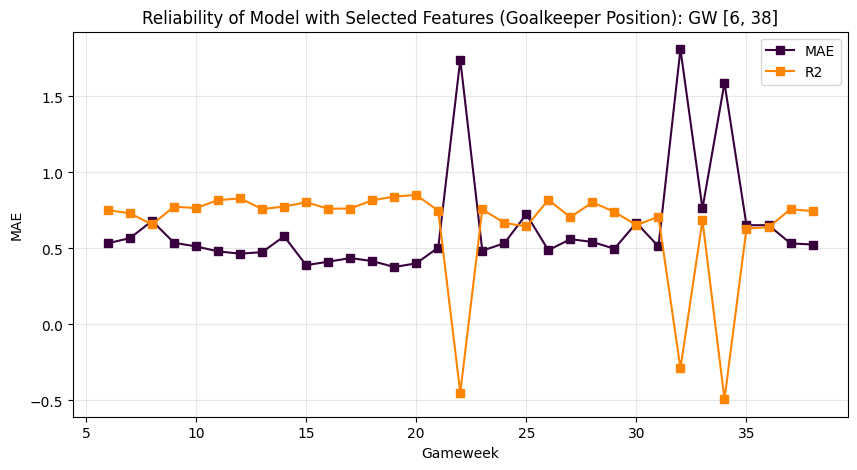

In [4]:
# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(mae_by_round.keys(), mae_by_round.values(), marker='s', color="#38003c", label='MAE')

plt.plot(r2_by_round.keys(), r2_by_round.values(), marker='s', color="#ff8400", label='R2')
plt.title('Reliability of Model with Selected Features (Goalkeeper Position): GW [6, 38]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

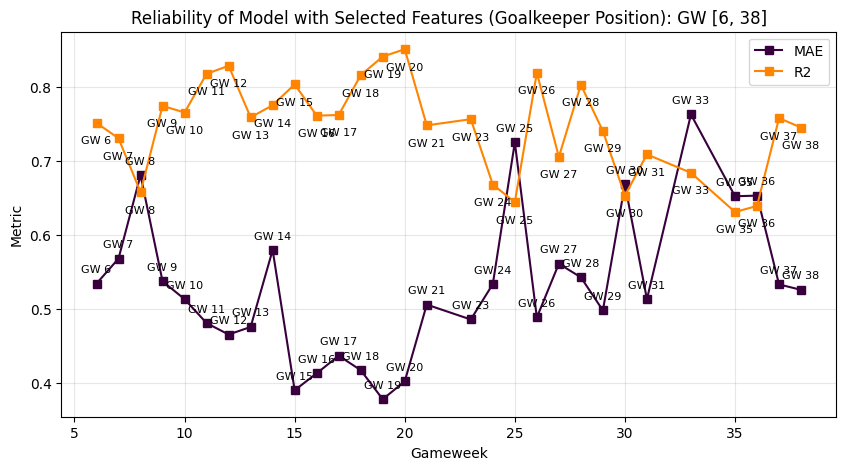

In [5]:
mae_by_round.pop(22, None)
r2_by_round.pop(22, None)

mae_by_round.pop(32, None)
r2_by_round.pop(32, None)

mae_by_round.pop(34, None)
r2_by_round.pop(34, None)

# --- Visualization ---
plt.figure(figsize=(10, 5))

# MAE
plt.plot(
    mae_by_round.keys(),
    mae_by_round.values(),
    marker='s',
    color="#38003c",
    label='MAE'
)

for round_, mae in mae_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, mae),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

# R2
plt.plot(
    r2_by_round.keys(),
    r2_by_round.values(),
    marker='s',
    color="#ff8400",
    label='R2'
)

for round_, r2 in r2_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, r2),
        xytext=(0, -15),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

plt.title(
    'Reliability of Model with Selected Features (Goalkeeper Position): GW [6, 38]',
    fontsize=12
)
plt.xlabel('Gameweek')
plt.ylabel('Metric')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [6]:
gk_preds.to_csv('./hist/gk_preds.csv', index=False)

## DEF


In [7]:
def_feats = joblib.load('./hist/feats_def')
def_models_by_round = joblib.load('./models_by_round_def')

def_data = data[data['position'] == 'Defender']

cached_model = None
mae_by_round = {}
r2_by_round = {}

def_preds = pd.DataFrame()

for ro in range(6, 39):

    preds = {}
    tar_feats = def_feats[ro].copy()
    tar_feats.remove('xP')

    X_train = def_data[def_data['round'] < ro][tar_feats]
    y_train = def_data[def_data['round'] < ro]['xP']
    c = abs(y_train.min()) + 1.0
    y_train_shifted = y_train + c

    X_test = def_data[def_data['round'] == ro][tar_feats]
    X_test_index = def_data[def_data['round'] == ro]['element']
    X_test_names = def_data[def_data['round'] == ro]['name']
    y_test = def_data[def_data['round'] == ro]['xP']


    if ro in [22, 32, 34]:
        model = cached_model
        tar_feats = def_feats[ro-1].copy()
        tar_feats.remove('xP')

        # X_train = def_data[def_data['round'] < ro][tar_feats]
        # y_train = def_data[def_data['round'] < ro]['xP']
        # c = abs(y_train.min()) + 1.0
        # y_train_shifted = y_train + c

        X_test = def_data[def_data['round'] == ro][tar_feats]
        X_test_index = def_data[def_data['round'] == ro]['element']
        X_test_names = def_data[def_data['round'] == ro]['name']
        y_test = def_data[def_data['round'] == ro]['xP']

    else:
        model = def_models_by_round[ro]

        best_model = model['best_model']

        if 'best_estimator' in def_models_by_round[ro]:
            model = def_models_by_round[ro]['best_estimator'].regressor # not fitted yet
        else:
            model = RandomForestRegressor()


        model.fit(X_train, y_train_shifted)

    xP_preds = model.predict(X_test) - c

    # print(f"Best Estimator for Round {ro}: {best_estimator}")

    xP_preds = model.predict(X_test) - c

    preds['element'] = X_test_index.values
    preds['name'] = X_test_names.values

    preds['xP_pred'] = xP_preds
    preds['xP_actual'] = y_test.values
    preds['round'] = ro

    mae = mean_absolute_error(y_test, xP_preds)
    rmse = np.sqrt(mean_squared_error(y_test, xP_preds))
    r2 = r2_score(y_test, xP_preds)

    mae_by_round[ro] = mae
    r2_by_round[ro] = r2

    print(f"Round {ro} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    def_preds = pd.concat([def_preds, pd.DataFrame(preds)], ignore_index=True)

    cached_model = model

def_preds



Round 6 - MAE: 0.4948, RMSE: 0.7848, R2: 0.7518
Round 7 - MAE: 0.6331, RMSE: 0.9186, R2: 0.6683
Round 8 - MAE: 0.6042, RMSE: 0.9294, R2: 0.6817
Round 9 - MAE: 0.5467, RMSE: 0.8326, R2: 0.7389
Round 10 - MAE: 0.6111, RMSE: 0.9425, R2: 0.6415
Round 11 - MAE: 0.5992, RMSE: 0.8720, R2: 0.6922
Round 12 - MAE: 0.6124, RMSE: 0.9871, R2: 0.5955
Round 13 - MAE: 0.4810, RMSE: 0.7165, R2: 0.7508
Round 14 - MAE: 0.6211, RMSE: 0.9678, R2: 0.6489
Round 15 - MAE: 0.5564, RMSE: 0.8206, R2: 0.6834
Round 16 - MAE: 0.5114, RMSE: 0.7920, R2: 0.7467
Round 17 - MAE: 0.4690, RMSE: 0.6991, R2: 0.7737
Round 18 - MAE: 0.5007, RMSE: 0.7202, R2: 0.7936
Round 19 - MAE: 0.4697, RMSE: 0.6918, R2: 0.8215
Round 20 - MAE: 0.5023, RMSE: 0.7594, R2: 0.7548
Round 21 - MAE: 0.4465, RMSE: 0.6472, R2: 0.8031
Round 22 - MAE: 1.5174, RMSE: 2.1026, R2: -0.5607
Round 23 - MAE: 0.5061, RMSE: 0.7197, R2: 0.7663
Round 24 - MAE: 0.6554, RMSE: 1.1745, R2: 0.6211
Round 25 - MAE: 0.6059, RMSE: 0.9758, R2: 0.6930
Round 26 - MAE: 0.4874,

,element,name,xP_pred,xP_actual,round
0,3,Gabriel dos Santos Magalhães,5.671400,9.2,6
1,6,Jurriën Timber,4.512556,5.2,6
2,8,Jakub Kiwior,2.299901,1.8,6
3,18,William Saliba,4.245675,3.5,6
4,21,Kieran Tierney,0.302000,0.0,6
...,...,...,...,...,...
7971,796,Olabade Aluko,0.946000,-0.3,38
7972,799,Somto Boniface,0.203000,-0.5,38
7973,801,Brayden Clarke,1.622000,1.5,38
7974,803,Reece Welch,0.871000,0.9,38


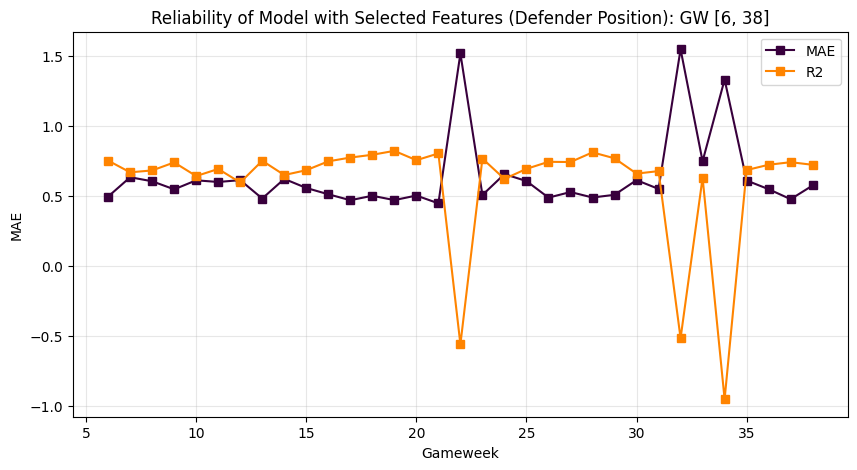

In [8]:
# mae_by_round.pop(34, None)
# r2_by_round.pop(22, None)

# mae_by_round.pop(32, None)
# r2_by_round.pop(32, None)

# mae_by_round.pop(34, None)
# r2_by_round.pop(34, None)

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(mae_by_round.keys(), mae_by_round.values(), marker='s', color="#38003c", label='MAE')

plt.plot(r2_by_round.keys(), r2_by_round.values(), marker='s', color="#ff8400", label='R2')
plt.title('Reliability of Model with Selected Features (Defender Position): GW [6, 38]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

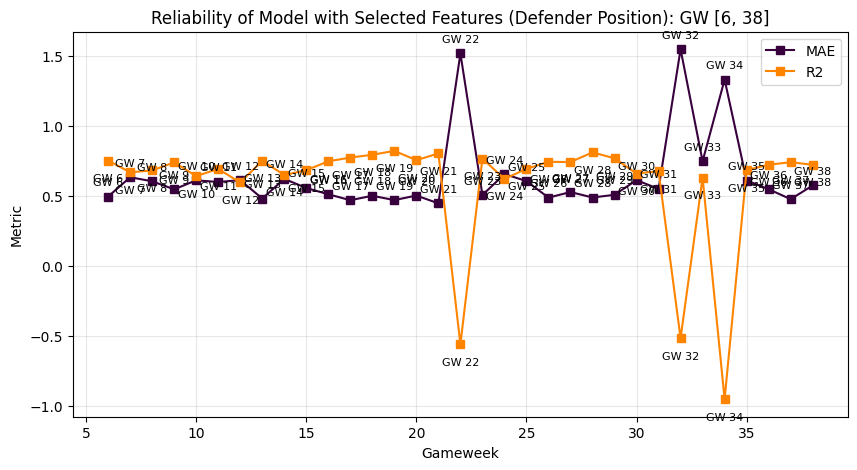

In [9]:
# --- Visualization ---
plt.figure(figsize=(10, 5))

# MAE
plt.plot(
    mae_by_round.keys(),
    mae_by_round.values(),
    marker='s',
    color="#38003c",
    label='MAE'
)

for round_, mae in mae_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, mae),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

# R2
plt.plot(
    r2_by_round.keys(),
    r2_by_round.values(),
    marker='s',
    color="#ff8400",
    label='R2'
)

for round_, r2 in r2_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, r2),
        xytext=(0, -15),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

plt.title(
    'Reliability of Model with Selected Features (Defender Position): GW [6, 38]',
    fontsize=12
)
plt.xlabel('Gameweek')
plt.ylabel('Metric')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [10]:
def_preds.to_csv('./hist/def_preds.csv', index=False)

## MID


In [11]:
mid_feats = joblib.load('./hist/feats_mid')
mid_models_by_round = joblib.load('./models_by_round_mid')

mid_data = data[data['position'] == 'Midfielder']

cached_model = None
mae_by_round = {}
r2_by_round = {}

mid_preds = pd.DataFrame()

for ro in range(6, 39):

    preds = {}
    tar_feats = mid_feats[ro].copy()
    tar_feats.remove('xP')

    X_train = mid_data[mid_data['round'] < ro][tar_feats]
    y_train = mid_data[mid_data['round'] < ro]['xP']
    c = abs(y_train.min()) + 1.0
    y_train_shifted = y_train + c

    X_test = mid_data[mid_data['round'] == ro][tar_feats]
    X_test_index = mid_data[mid_data['round'] == ro]['element']
    X_test_names = mid_data[mid_data['round'] == ro]['name']
    y_test = mid_data[mid_data['round'] == ro]['xP']


    if ro in [22, 32, 34]:
        model = cached_model
        tar_feats = mid_feats[ro-1].copy()
        tar_feats.remove('xP')

        # X_train = mid_data[mid_data['round'] < ro][tar_feats]
        # y_train = mid_data[mid_data['round'] < ro]['xP']
        # c = abs(y_train.min()) + 1.0
        # y_train_shifted = y_train + c

        X_test = mid_data[mid_data['round'] == ro][tar_feats]
        X_test_index = mid_data[mid_data['round'] == ro]['element']
        X_test_names = mid_data[mid_data['round'] == ro]['name']
        y_test = mid_data[mid_data['round'] == ro]['xP']

    else:
        model = mid_models_by_round[ro]

        best_model = model['best_model']

        if 'best_estimator' in mid_models_by_round[ro]:
            model = mid_models_by_round[ro]['best_estimator'].regressor # not fitted yet
        else:
            model = RandomForestRegressor()


        model.fit(X_train, y_train_shifted)

    xP_preds = model.predict(X_test) - c

    # print(f"Best Estimator for Round {ro}: {best_estimator}")

    xP_preds = model.predict(X_test) - c

    preds['element'] = X_test_index.values
    preds['name'] = X_test_names.values

    preds['xP_pred'] = xP_preds
    preds['xP_actual'] = y_test.values
    preds['round'] = ro

    mae = mean_absolute_error(y_test, xP_preds)
    rmse = np.sqrt(mean_squared_error(y_test, xP_preds))
    r2 = r2_score(y_test, xP_preds)

    mae_by_round[ro] = mae
    r2_by_round[ro] = r2

    print(f"Round {ro} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    mid_preds = pd.concat([mid_preds, pd.DataFrame(preds)], ignore_index=True)

    cached_model = model

mid_preds



Round 6 - MAE: 0.6410, RMSE: 1.0446, R2: 0.6899
Round 7 - MAE: 0.5624, RMSE: 0.8649, R2: 0.7799
Round 8 - MAE: 0.6052, RMSE: 0.9822, R2: 0.7374
Round 9 - MAE: 0.5930, RMSE: 0.9335, R2: 0.7062
Round 10 - MAE: 0.5673, RMSE: 0.8807, R2: 0.7236
Round 11 - MAE: 0.5465, RMSE: 0.8911, R2: 0.7385
Round 12 - MAE: 0.6034, RMSE: 1.0271, R2: 0.6933
Round 13 - MAE: 0.4644, RMSE: 0.8289, R2: 0.8033
Round 14 - MAE: 0.5830, RMSE: 0.9064, R2: 0.7944
Round 15 - MAE: 0.5547, RMSE: 0.9318, R2: 0.7658
Round 16 - MAE: 0.5282, RMSE: 0.8880, R2: 0.7980
Round 17 - MAE: 0.5258, RMSE: 0.9594, R2: 0.7472
Round 18 - MAE: 0.4550, RMSE: 0.7202, R2: 0.8506
Round 19 - MAE: 0.4951, RMSE: 0.7955, R2: 0.8136
Round 20 - MAE: 0.5255, RMSE: 0.8376, R2: 0.7963
Round 21 - MAE: 0.4985, RMSE: 0.7975, R2: 0.8037
Round 22 - MAE: 1.6673, RMSE: 2.2826, R2: -0.8077
Round 23 - MAE: 0.5550, RMSE: 0.9077, R2: 0.7767
Round 24 - MAE: 0.6601, RMSE: 1.1837, R2: 0.6937
Round 25 - MAE: 0.7432, RMSE: 1.4789, R2: 0.6000
Round 26 - MAE: 0.5858,

,element,name,xP_pred,xP_actual,round
0,1,Fábio Ferreira Vieira,0.601603,0.0,6
1,7,Jorge Luiz Frello Filho,0.587498,2.2,6
2,9,Gabriel Martinelli Silva,4.218400,8.5,6
3,10,Reiss Nelson,5.385000,2.7,6
4,12,Ethan Nwaneri,0.743770,2.2,6
...,...,...,...,...,...
10619,793,Jack Henry-Francis,1.227000,1.5,38
10620,795,Harry Howell,0.669000,0.2,38
10621,797,Jake Evans,-0.084000,0.3,38
10622,800,Tom Taylor,0.107000,-0.5,38


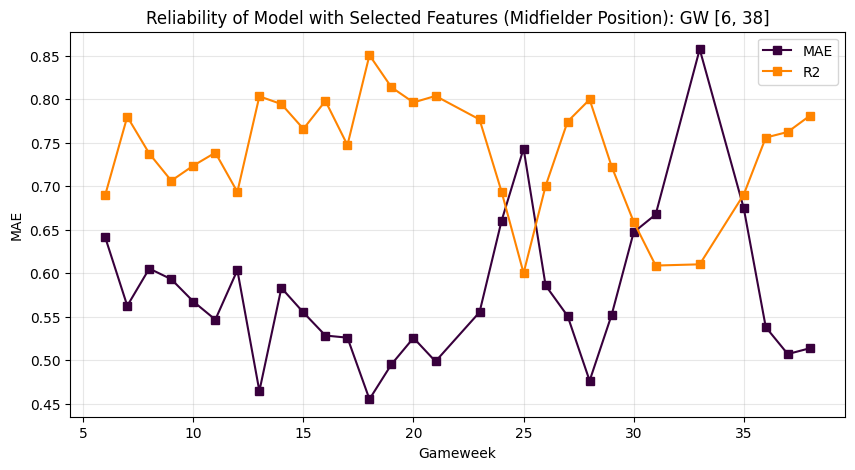

In [12]:
mae_by_round.pop(22, None)
r2_by_round.pop(22, None)

mae_by_round.pop(32, None)
r2_by_round.pop(32, None)

mae_by_round.pop(34, None)
r2_by_round.pop(34, None)

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(mae_by_round.keys(), mae_by_round.values(), marker='s', color="#38003c", label='MAE')

plt.plot(r2_by_round.keys(), r2_by_round.values(), marker='s', color="#ff8400", label='R2')
plt.title('Reliability of Model with Selected Features (Midfielder Position): GW [6, 38]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

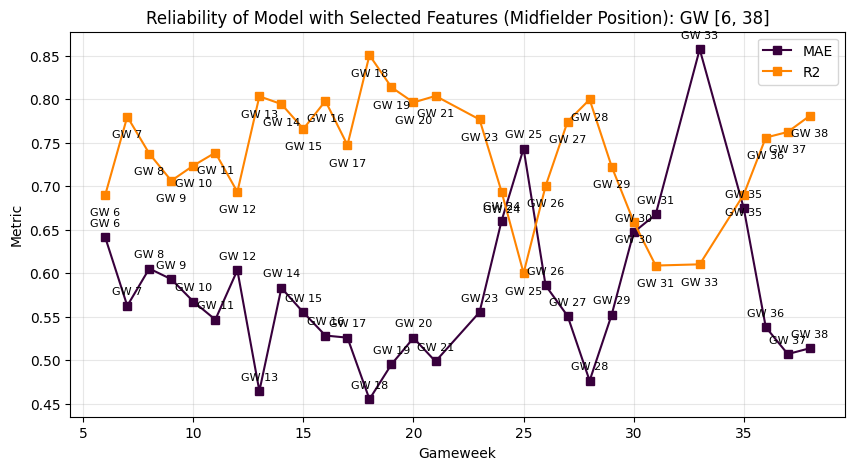

In [13]:
mae_by_round.pop(22, None)
r2_by_round.pop(22, None)

mae_by_round.pop(32, None)
r2_by_round.pop(32, None)

mae_by_round.pop(34, None)
r2_by_round.pop(34, None)

# --- Visualization ---
plt.figure(figsize=(10, 5))

# MAE
plt.plot(
    mae_by_round.keys(),
    mae_by_round.values(),
    marker='s',
    color="#38003c",
    label='MAE'
)

for round_, mae in mae_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, mae),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

# R2
plt.plot(
    r2_by_round.keys(),
    r2_by_round.values(),
    marker='s',
    color="#ff8400",
    label='R2'
)

for round_, r2 in r2_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, r2),
        xytext=(0, -15),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

plt.title(
    'Reliability of Model with Selected Features (Midfielder Position): GW [6, 38]',
    fontsize=12
)
plt.xlabel('Gameweek')
plt.ylabel('Metric')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [14]:
mid_preds.to_csv('./hist/mid_preds.csv', index=False)

## FWD


In [15]:
fwd_feats = joblib.load('./hist/feats_fwd')
fwd_models_by_round = joblib.load('./models_by_round_fwd')

fwd_data = data[data['position'] == 'Forward']

cached_model = None
mae_by_round = {}
r2_by_round = {}

fwd_preds = pd.DataFrame()

for ro in range(6, 39):

    preds = {}
    tar_feats = fwd_feats[ro].copy()
    tar_feats.remove('xP')

    X_train = fwd_data[fwd_data['round'] < ro][tar_feats]
    y_train = fwd_data[fwd_data['round'] < ro]['xP']
    c = abs(y_train.min()) + 1.0
    y_train_shifted = y_train + c

    X_test = fwd_data[fwd_data['round'] == ro][tar_feats]
    X_test_index = fwd_data[fwd_data['round'] == ro]['element']
    X_test_names = fwd_data[fwd_data['round'] == ro]['name']
    y_test = fwd_data[fwd_data['round'] == ro]['xP']


    if ro in [22, 32, 34]:
        model = cached_model
        tar_feats = fwd_feats[ro-1].copy()
        tar_feats.remove('xP')

        # X_train = fwd_data[fwd_data['round'] < ro][tar_feats]
        # y_train = fwd_data[fwd_data['round'] < ro]['xP']
        # c = abs(y_train.min()) + 1.0
        # y_train_shifted = y_train + c

        X_test = fwd_data[fwd_data['round'] == ro][tar_feats]
        X_test_index = fwd_data[fwd_data['round'] == ro]['element']
        X_test_names = fwd_data[fwd_data['round'] == ro]['name']
        y_test = fwd_data[fwd_data['round'] == ro]['xP']

    else:
        model = fwd_models_by_round[ro]

        best_model = model['best_model']

        if 'best_estimator' in fwd_models_by_round[ro]:
            model = fwd_models_by_round[ro]['best_estimator'].regressor # not fitted yet
        else:
            model = RandomForestRegressor()


        model.fit(X_train, y_train_shifted)

    xP_preds = model.predict(X_test) - c

    # print(f"Best Estimator for Round {ro}: {best_estimator}")

    xP_preds = model.predict(X_test) - c

    preds['element'] = X_test_index.values
    preds['name'] = X_test_names.values

    preds['xP_pred'] = xP_preds
    preds['xP_actual'] = y_test.values
    preds['round'] = ro

    mae = mean_absolute_error(y_test, xP_preds)
    rmse = np.sqrt(mean_squared_error(y_test, xP_preds))
    r2 = r2_score(y_test, xP_preds)

    mae_by_round[ro] = mae
    r2_by_round[ro] = r2

    print(f"Round {ro} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    fwd_preds = pd.concat([fwd_preds, pd.DataFrame(preds)], ignore_index=True)

    cached_model = model

fwd_preds



Round 6 - MAE: 0.7451, RMSE: 1.2710, R2: 0.6923
Round 7 - MAE: 0.6223, RMSE: 1.0360, R2: 0.7780
Round 8 - MAE: 0.6875, RMSE: 1.1093, R2: 0.7438
Round 9 - MAE: 0.7499, RMSE: 1.1951, R2: 0.7313
Round 10 - MAE: 0.7391, RMSE: 1.1927, R2: 0.7085
Round 11 - MAE: 0.7899, RMSE: 1.2973, R2: 0.7193
Round 12 - MAE: 0.7120, RMSE: 1.1641, R2: 0.7574
Round 13 - MAE: 0.5950, RMSE: 0.9815, R2: 0.8059
Round 14 - MAE: 0.5038, RMSE: 0.7375, R2: 0.8717
Round 15 - MAE: 0.5688, RMSE: 0.8480, R2: 0.8197
Round 16 - MAE: 0.4481, RMSE: 0.6786, R2: 0.8723
Round 17 - MAE: 0.4868, RMSE: 0.8035, R2: 0.8207
Round 18 - MAE: 0.5050, RMSE: 0.8376, R2: 0.8169
Round 19 - MAE: 0.4946, RMSE: 0.8016, R2: 0.8371
Round 20 - MAE: 0.5595, RMSE: 0.9293, R2: 0.8005
Round 21 - MAE: 0.5635, RMSE: 0.9896, R2: 0.7153
Round 22 - MAE: 1.7948, RMSE: 2.3827, R2: -1.1680
Round 23 - MAE: 0.7342, RMSE: 1.2088, R2: 0.7214
Round 24 - MAE: 0.9503, RMSE: 1.7423, R2: 0.6107
Round 25 - MAE: 0.9526, RMSE: 1.5586, R2: 0.6165
Round 26 - MAE: 0.4712,

,element,name,xP_pred,xP_actual,round
0,2,Gabriel Fernando de Jesus,0.842000,2.2,6
1,4,Kai Havertz,2.750000,4.8,6
2,11,Eddie Nketiah,1.834833,1.5,6
3,27,Cameron Archer,1.342333,0.2,6
4,38,Jhon Durán,4.908950,4.5,6
...,...,...,...,...,...
2617,780,Iwan Morgan,0.095000,0.0,38
2618,781,Shumaira Mheuka,0.281000,-0.5,38
2619,784,Mateus Mané,0.112000,0.2,38
2620,789,Sean Neave,0.391000,0.5,38


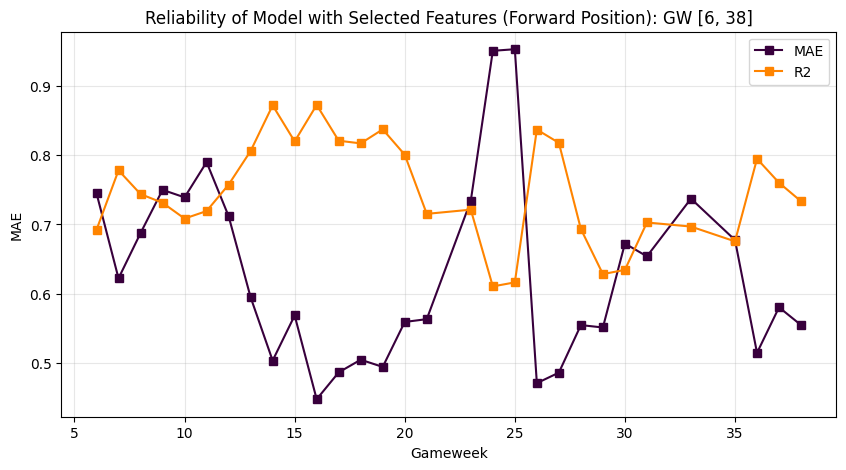

In [16]:
mae_by_round.pop(22, None)
r2_by_round.pop(22, None)

mae_by_round.pop(32, None)
r2_by_round.pop(32, None)

mae_by_round.pop(34, None)
r2_by_round.pop(34, None)

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(mae_by_round.keys(), mae_by_round.values(), marker='s', color="#38003c", label='MAE')

plt.plot(r2_by_round.keys(), r2_by_round.values(), marker='s', color="#ff8400", label='R2')
plt.title('Reliability of Model with Selected Features (Forward Position): GW [6, 38]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

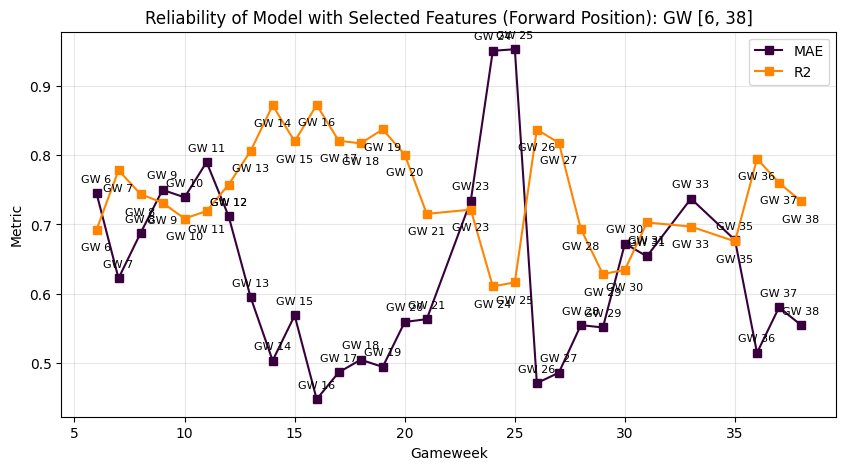

In [17]:
mae_by_round.pop(22, None)
r2_by_round.pop(22, None)

mae_by_round.pop(32, None)
r2_by_round.pop(32, None)

mae_by_round.pop(34, None)
r2_by_round.pop(34, None)

# --- Visualization ---
plt.figure(figsize=(10, 5))

# MAE
plt.plot(
    mae_by_round.keys(),
    mae_by_round.values(),
    marker='s',
    color="#38003c",
    label='MAE'
)

for round_, mae in mae_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, mae),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

# R2
plt.plot(
    r2_by_round.keys(),
    r2_by_round.values(),
    marker='s',
    color="#ff8400",
    label='R2'
)

for round_, r2 in r2_by_round.items():
    plt.annotate(
        f'GW {round_}',
        (round_, r2),
        xytext=(0, -15),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

plt.title(
    'Reliability of Model with Selected Features (Forward Position): GW [6, 38]',
    fontsize=12
)
plt.xlabel('Gameweek')
plt.ylabel('Metric')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [18]:
fwd_preds.to_csv('./hist/fwd_preds.csv', index=False)